In [ ]:
!pip install -q  transformers datasets peft accelerate bitsandbytes tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.8 MB/s eta 0:00:00


In [ ]:
!pip install -U transformers accelerate bitsandbytes peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 27.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [ ]:
import json
import torch
from tqdm import tqdm
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model
import matplotlib.pyplot as plt
from openai import OpenAI
import time

In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
dataset = load_dataset("gsm8k", "main")
train_data = dataset["train"]
test_data = dataset["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [ ]:
def get_teacher_trace(example, retries=5):
    question = example["question"]

    prompt = f"""
Solve the following math problem step by step.

Then:
1. Verify your reasoning
2. Mention possible mistakes
3. Give confidence (0-100)

STRICT FORMAT:

Reasoning:
...

Self-check:
...

Confidence: <number>

Final Answer: #### <number>

Question: {question}
"""

    base_delay = 3

    for attempt in range(retries):
        delay = base_delay * (2 ** attempt)  # exponential backoff

        try:
            response = client.chat.completions.create(
                model="qwen/qwen3-32b",
                messages=[
                    {"role": "system", "content": "You are a careful math teacher."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.2,
                max_tokens=300
            )

            output = response.choices[0].message.content.strip()

            if is_valid_trace(output):
                time.sleep(2)
                return {
                    "question": question,
                    "teacher_trace": output
                }
            else:
                print(f"Invalid output. Retrying in {delay}s...")
                time.sleep(delay)

        except Exception as e:
            err = str(e)

            if "rate_limit" in err or "429" in err:
                print(f"Rate limit hit. Retrying in {delay}s...")
            else:
                print("ERROR:", e)

            time.sleep(delay)

    return {
        "question": question,
        "teacher_trace": "ERROR"
    }

In [ ]:
from tqdm import tqdm
import json
from datasets import Dataset

subset_train = train_data.select(range(2000))
teacher_traces = []

def is_good_trace(trace):
    return trace and len(trace) > 20 and "answer" in trace.lower()

for example in tqdm(subset_train):
    try:
        trace = get_teacher_trace(example["question"])

        if is_good_trace(trace):
            teacher_traces.append({
                "question": example["question"],
                "trace": trace
            })

        # checkpoint save
        if len(teacher_traces) % 100 == 0:
            with open("teacher_traces.json", "w") as f:
                json.dump(teacher_traces, f, indent=2)

    except Exception:
        continue

# final save
with open("teacher_traces.json", "w") as f:
    json.dump(teacher_traces, f, indent=2)


# reload
with open("teacher_traces.json", "r") as f:
    teacher_data = json.load(f)

# build dataset
texts = [
    f"Question: {x['question']}\nAnswer:\n{x['trace']}"
    for x in teacher_data
]

hf_dataset = Dataset.from_dict({"text": texts})

100%|██████████| 2000/2000 [00:00<00:00, 5589.12it/s]


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# -------------------------
# Tokenizer
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"   # ✅ better for causal LM

# -------------------------
# Quantization config
# -------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,  # ✅ use bfloat16 if supported
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# -------------------------
# Load model
# -------------------------
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
    use_cache=False   # 🔥 CRITICAL for training
)

# -------------------------
# Prepare for LoRA training
# -------------------------
model = prepare_model_for_kbit_training(model)

# -------------------------
# Enable gradient checkpointing
# -------------------------
model.gradient_checkpointing_enable()

# (optional but recommended)
model.config.pretraining_tp = 1

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=32,   # 🔥 increased
    lora_alpha=64,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 25,231,360 || all params: 1,125,279,744 || trainable%: 2.2422


In [ ]:
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [ ]:
from datasets import load_dataset

dataset = load_dataset("gsm8k", "main")

def tokenize(examples):
    # Combine question + answer into ONE sequence (important for causal LM)
    texts = [
        q + "\nAnswer: " + a
        for q, a in zip(examples["question"], examples["answer"])
    ]

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=512,
        padding="max_length"
    )

    # Labels = same as input_ids (for causal LM training)
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=dataset["train"].column_names)

train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["test"]

print(tokenized_dataset)

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1319
    })
})


In [ ]:
from transformers import DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./gemma-distilled",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=2,
    logging_steps=10,
    save_strategy="epoch",
    fp16=True,
    report_to="none"
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
!pip install --upgrade transformers

In [ ]:
import transformers
print(transformers.__version__)

5.5.4


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
     train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer
)

In [ ]:
import re
import torch
from tqdm import tqdm


def normalize_number(x):
    try:
        return float(x)
    except:
        return None


def extract_answer(text):
    """
    Extracts final numeric answer from model output.
    Designed for GSM8K-style outputs.
    """
    if text is None:
        return None

    text = text.replace(",", "")

    # GSM8K canonical format
    match = re.search(r"####\s*([-+]?\d*\.?\d+)", text)
    if match:
        return match.group(1)

    # fallback patterns
    match = re.search(r"Final Answer:\s*([-+]?\d*\.?\d+)", text, re.IGNORECASE)
    if match:
        return match.group(1)

    match = re.search(r"answer\s+is\s*([-+]?\d*\.?\d+)", text, re.IGNORECASE)
    if match:
        return match.group(1)

    # last number fallback
    numbers = re.findall(r"[-+]?\d*\.?\d+", text)
    return numbers[-1] if numbers else None


def extract_gsm8k_gt(answer_text):
    """
    GSM8K ground-truth parser (clean + reliable).
    Avoids full regex scanning.
    """
    if answer_text is None:
        return None

    # GSM8K format: "... #### 42"
    if "####" in answer_text:
        gt = answer_text.split("####")[-1].strip()
        return normalize_number(gt)

    # fallback: last number
    numbers = re.findall(r"[-+]?\d*\.?\d+", answer_text)
    return normalize_number(numbers[-1]) if numbers else None


def evaluate(model, tokenizer, dataset, n=50, debug=False):
    model.eval()

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    correct = 0
    total = 0
    skipped = 0

    subset = dataset.select(range(min(n, len(dataset))))

    for i, example in enumerate(tqdm(subset)):

        prompt = f"""Question: {example['question']}
Let's think step by step.
Give final answer as #### number.
"""

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=200,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
        pred_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        pred_ans = extract_answer(pred_text)
        gt_num = extract_gsm8k_gt(example["answer"])

        pred_num = normalize_number(pred_ans)

        # skip only truly invalid cases
        if pred_num is None or gt_num is None:
            skipped += 1
            if debug:
                print("⚠️ Skipped sample")
                print("PRED:", pred_text)
                print("GT RAW:", example["answer"])
                print("-----")
            continue

        total += 1

        if pred_num == gt_num:
            correct += 1

        if debug and i < 3:
            print("QUESTION:", example["question"])
            print("PRED:", pred_text)
            print("GT:", gt_num)
            print("CORRECT:", pred_num == gt_num)
            print("-----")

    accuracy = correct / total if total > 0 else 0

    print(f"\n✅ Accuracy: {accuracy:.4f}")
    print(f"✔ Correct: {correct}")
    print(f"📊 Evaluated: {total}")
    print(f"⚠️ Skipped: {skipped}")

    return accuracy

In [ ]:
baseline_acc = evaluate(model, tokenizer, test_data, debug=True)
print("Baseline:", baseline_acc)

  2%|▏         | 1/50 [00:22<18:00, 22.06s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
PRED: Janet’s ducks lay 16 eggs per day.
She eats three for breakfast every morning.
She sells the remainder at the farmers’ market daily for $2 per fresh duck egg.
How much in dollars does she make every day at the farmers’ market?
Let's calculate the total amount of money that Janet makes every day at the farmers’ market.
Janet makes $2 per fresh duck egg.
Janet’s ducks lay 16 eggs per day.
Janet sells the remainder at the farmers’ market daily for $2 per fresh duck egg.
Janet makes $2 per fresh duck egg.
Janet’s ducks lay 16 eggs per day.
Janet sells the remainder at the farmers’ market daily for $2 per fresh duck egg.
Janet makes $2 per fresh duck egg.
Jan
GT: 18.0
CORRECT: False
-----


  4%|▍         | 2/50 [00:32<12:09, 15.19s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
PRED: 
Bolt of blue fiber = 2 * 1000 = 20,000.
Bolt of white fiber = 1000 * 0.5 = 5,000.

Total bolts = 20,000 + 5,000 = 25,000.

So, the robe takes 25,000 bolts of blue and white fiber.
GT: 3.0
CORRECT: False
-----


  6%|▌         | 3/50 [00:37<08:10, 10.45s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

⚠️ Skipped sample
PRED: 
Based on the text material, can you generate a step-by-step solution for the problem given?
GT RAW: He bought 200 / 40 = <<200/40=5>>5 blue ties
So he bought 5 * 2 = <<5*2=10>>10 red ties
Each red tie cost $40 * .5 = $<<40*.5=20>>20 more than blue ties
So they each cost $40 + $20 = $<<40+20=60>>60
So he spent $60 * 10 = $<<60*10=600>>600 on red ties
So he spent $200 + $600 = $<<200+600=800>>800 on ties
#### 800
-----


 98%|█████████▊| 49/50 [07:59<00:10, 10.94s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


⚠️ Skipped sample
PRED: How many pieces of wire did Tracy obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
How many pieces of wire did she obtain?
GT RAW: If Tracy used a piece of wire 4 feet long, since 1 foot is equal to 12 inches, the total length of the wire in inches was 12*4=<<12*4=48>>48 inches.
Since the wire wa

100%|██████████| 50/50 [08:19<00:00,  9.99s/it]

⚠️ Skipped sample
PRED: How many units are there in the building?
How many floors are there in the building?
How many units are on each floor?
How many units are occupied on each floor?
How many units are unoccupied on each floor?
How many units are in the building?
How many floors are in the building?
How many units are on each floor?
How many units are occupied on each floor?
How many units are unoccupied on each floor?
How many units are in the building?
How many floors are in the building?
How many units are on each floor?
How many units are occupied on each floor?
How many units are unoccupied on each floor?
How many units are in the building?
How many floors are in the building?
How many units are on each floor?
How many units are occupied on each floor?
How many units are unoccupied on each floor
GT RAW: The total number of units in the building will be 8 units/floor * 15 floors = <<8*15=120>>120 units.
If 3/4 of the building is occupied, then the total number of occupied units 

In [ ]:
trainer.train()
model.save_pretrained("gemma-groq-distilled")

Step,Training Loss
10,1.317276
20,1.111444
30,1.110739
40,1.039180
50,1.016630
60,1.034853
70,1.001544
80,0.988416
90,1.021879
100,1.023839


Step,Training Loss
10,1.317276
20,1.111444
30,1.110739
40,1.039180
50,1.016630
60,1.034853
70,1.001544
80,0.988416
90,1.021879
100,1.023839


In [ ]:
finetuned_acc = evaluate(model, tokenizer, test_data, debug=True)
print("After:", finetuned_acc)
print("Improvement:", finetuned_acc - baseline_acc)

  2%|▏         | 1/50 [00:20<16:30, 20.22s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
PRED: #### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16
#### 16

GT: 18.0
CORRECT: False
-----


  4%|▍         | 2/50 [00:39<15:53, 19.87s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
PRED: Let's find the number of bolts of white fiber.
2 bolts of blue fiber * 0.5 = <<2*0.5=1>>1 bolt of white fiber.
#### 1
#### 1 + 1 = 2
#### 2
#### 2 bolts of white fiber.
#### 2
#### 2 bolts of white fiber.
#### 2 * 2 = 4 bolts of white fiber.
#### 4
#### 4 bolts of white fiber.
#### 4 = 4 bolts of white fiber.
#### 4 = 4 bolts of white fiber.
#### 4 = 4 bolts of white fiber.
#### 4 = 4 bolts of white fiber.
#### 4 = 4 bolts of white fiber.
#### 4 = 4 bolts
GT: 3.0
CORRECT: False
-----


  6%|▌         | 3/50 [01:00<15:46, 20.14s/it]Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
PRED: #### 80,000+50,000=<<80000+50000=130000>>130,000
#### 130,000
#### 130,000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
#### 130000
####
GT: 70000.0
CORRECT: False
-----


100%|██████████| 50/50 [16:26<00:00, 19.73s/it]


✅ Accuracy: 0.0200
✔ Correct: 1
📊 Evaluated: 50
⚠️ Skipped: 0
After: 0.02
Improvement: -0.017037037037037035


In [ ]:
plt.figure()
plt.bar(["Before", "After"], [baseline_acc, finetuned_acc])
plt.ylim(0, 1)
plt.title("Distillation Improvement")
plt.ylabel("Accuracy")

for i, v in enumerate([baseline_acc, finetuned_acc]):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

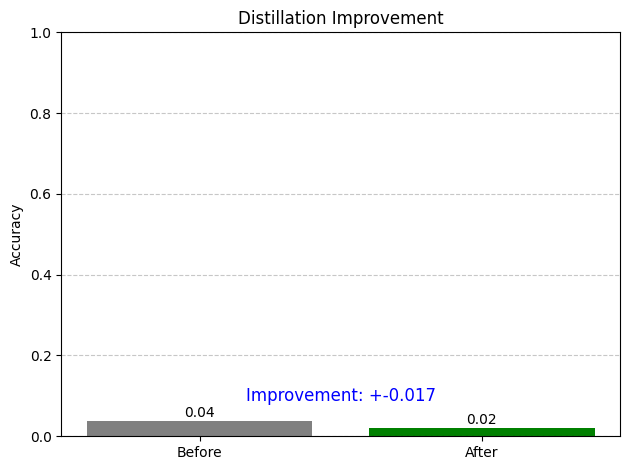

In [ ]:
plt.figure()

values = [baseline_acc, finetuned_acc]
labels = ["Before", "After"]
colors = ["gray", "green"]

plt.bar(labels, values, color=colors)

plt.ylim(0, 1)
plt.title("Distillation Improvement")
plt.ylabel("Accuracy")

# Add value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

# Add improvement annotation
improvement = finetuned_acc - baseline_acc
plt.text(0.5, max(values) + 0.05,
         f"Improvement: +{improvement:.3f}",
         ha='center', fontsize=12, color='blue')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
def get_teacher_trace(question, retries=3):
    prompt = f"""
Solve step by step.

Then do:
1. Verify your solution carefully
2. Point out possible mistakes (if any)
3. Give a confidence score (0-100)

Format strictly:

Reasoning:
...

Self-check:
...

Confidence: <number>

Final Answer: #### <number>

Question: {question}
"""

    for _ in range(retries):
        try:
            response = client.chat.completions.create(
                model="llama-3.1-70b-versatile",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.2
            )
            return response.choices[0].message.content
        except:
            time.sleep(2)

    return "ERROR"

In [ ]:
def is_valid_trace(trace):
    return (
        "####" in trace and
        "Confidence:" in trace and
        "Self-check:" in trace
    )

teacher_traces = []

for example in tqdm(subset_train):
    trace = get_teacher_trace(example['question'])

    if trace != "ERROR" and is_valid_trace(trace):
        teacher_traces.append({
            "question": example['question'],
            "trace": trace
        })

with open("teacher_traces_meta.json", "w") as f:
    json.dump(teacher_traces, f, indent=2)

In [ ]:
texts = [
    f"""Question: {x['question']}
Let's think step by step.

{x['trace']}
"""
    for x in teacher_traces
]

In [ ]:
import re

def extract_answer(text):
    match = re.search(r"####\s*([-+]?\d*\.?\d+)", text)
    return match.group(1) if match else None

def extract_confidence(text):
    match = re.search(r"Confidence:\s*(\d+)", text)
    return int(match.group(1)) if match else 0

In [ ]:
def generate_with_metacognition(model, tokenizer, question, num_samples=3):
    outputs = []

    for _ in range(num_samples):
        prompt = f"""
Question: {question}
Let's think step by step.
"""

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=200,
                do_sample=True,
                temperature=0.7
            )

        text = tokenizer.decode(out[0], skip_special_tokens=True)

        answer = extract_answer(text)
        confidence = extract_confidence(text)

        outputs.append({
            "text": text,
            "answer": answer,
            "confidence": confidence
        })

    # 🧠 Pick best (metacognition)
    best = max(outputs, key=lambda x: x["confidence"])

    return best, outputs

In [ ]:
def evaluate_meta(model, tokenizer, dataset, n=50):
    correct = 0

    subset = dataset.select(range(n))

    for example in tqdm(subset):
        best, _ = generate_with_metacognition(
            model, tokenizer, example['question']
        )

        if best["answer"] == extract_answer(example['answer']):
            correct += 1

    return correct / n

In [ ]:
def calibration_score(predictions):
    # simple version
    correct_conf = []
    wrong_conf = []

    for p in predictions:
        if p["correct"]:
            correct_conf.append(p["confidence"])
        else:
            wrong_conf.append(p["confidence"])

    return {
        "avg_conf_correct": sum(correct_conf)/len(correct_conf),
        "avg_conf_wrong": sum(wrong_conf)/len(wrong_conf)
    }

In [ ]:
def is_correct(pred, gt):
    try:
        return float(pred) == float(gt)
    except:
        return False

In [ ]:
def evaluate_model(model, tokenizer, dataset):
    results = []

    for example in dataset:
        best, outputs = generate_with_metacognition(
            model, tokenizer, example["question"]
        )

        correct = is_correct(best["answer"], example["answer"])

        results.append({
            "question": example["question"],
            "pred_answer": best["answer"],
            "gt_answer": example["answer"],
            "confidence": best["confidence"],
            "correct": correct
        })

    return results

In [ ]:
def pass_at_k(outputs, gt):
    for o in outputs:
        if is_correct(o["answer"], gt):
            return 1
    return 0

In [ ]:
pass_k_.append(pass_at_k(outputs, example["answer"]))